# MITGCM Mixed Layer depth Analysis 

**Purpose**: Code for preforming the regional time scale analysis. I will compute the decorrelation time scale for a subset of the model domain at each grid point. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize, segment_time_series, bootstrap_decorrelation_scale, windowed_decorrelation_scale
from spectra import spectrum1D_frequency, spectral_slope
from lsf import unweighted_lsf, detrend
from structure_functions import compute_structure_function
from var_analysis import variance_scale_analysis_1D
from ocean_analysis import compute_mld
from plotScaleAnalysis import month_fmt

Set data analysis parameters

In [3]:
# Set processing parameters
option_plot          = 0      # Specifies if supplementary plots are plotted
option_var           = 'density'  # Specifies which variable will analyzed. Options include: temp, sal, density, u_along, v_cross
option_bin           = 0

# Set time and space parameters
T            = 1*(60)*(60)                   # Spcifies the time interval for model run. Units: seconds
estimator    = 'biased'                      # Specifies the approach for estimating the autocorrelation function    
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs_server/mitgcm/scale_analysis/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 16

# Set font and fontsize
plt.rcParams.update({
    "font.size": fontsize,                          # Fontsize
    "text.usetex": True,                           # Use LaTeX for all text
    "font.family": "serif",                         # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Load mitgcm data netcdf files 

In [4]:
#--- MITgcm Data ---# 
if (option_var == 'temp') | (option_var == 'sal') | (option_var == 'density'):
    filename = PATH + "mitgcm_intermediate_data_TSD_hrly_ts_profiles.nc"
elif (option_var == 'u_along') | (option_var == 'v_cross'):
    filename = PATH + "mitgcm_intermediate_data_vel_hrly_ts_profiles.nc"
nc = Dataset(filename, 'r')

# Extract data variables
depth = nc.variables['depth'][:]
lon   = nc.variables['LON'][:]
lat   = nc.variables['LAT'][:]
if option_bin == 1: 
    time  =  num2date(nc.variables['time_bin'][:], nc.variables['time_bin'].units)
else: 
    time  =  num2date(nc.variables['time'][:], nc.variables['time'].units)

if option_var == 'temp':
    data = nc.variables['CTemp'][:]
elif option_var == 'sal':
    data = nc.variables['ASal'][:]
elif option_var == 'density':
    data = nc.variables['SIG'][:]
elif option_var == 'u_along':
    if option_bin == 1: 
        data = nc.variables['u_along_bin'][:]
    else: 
        data = nc.variables['u_along'][:]
elif option_var == 'v_cross':
    if option_bin == 1: 
        data = nc.variables['v_cross_bin'][:]
    else: 
        data = nc.variables['v_cross'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Plot profile time series and time averaged profile

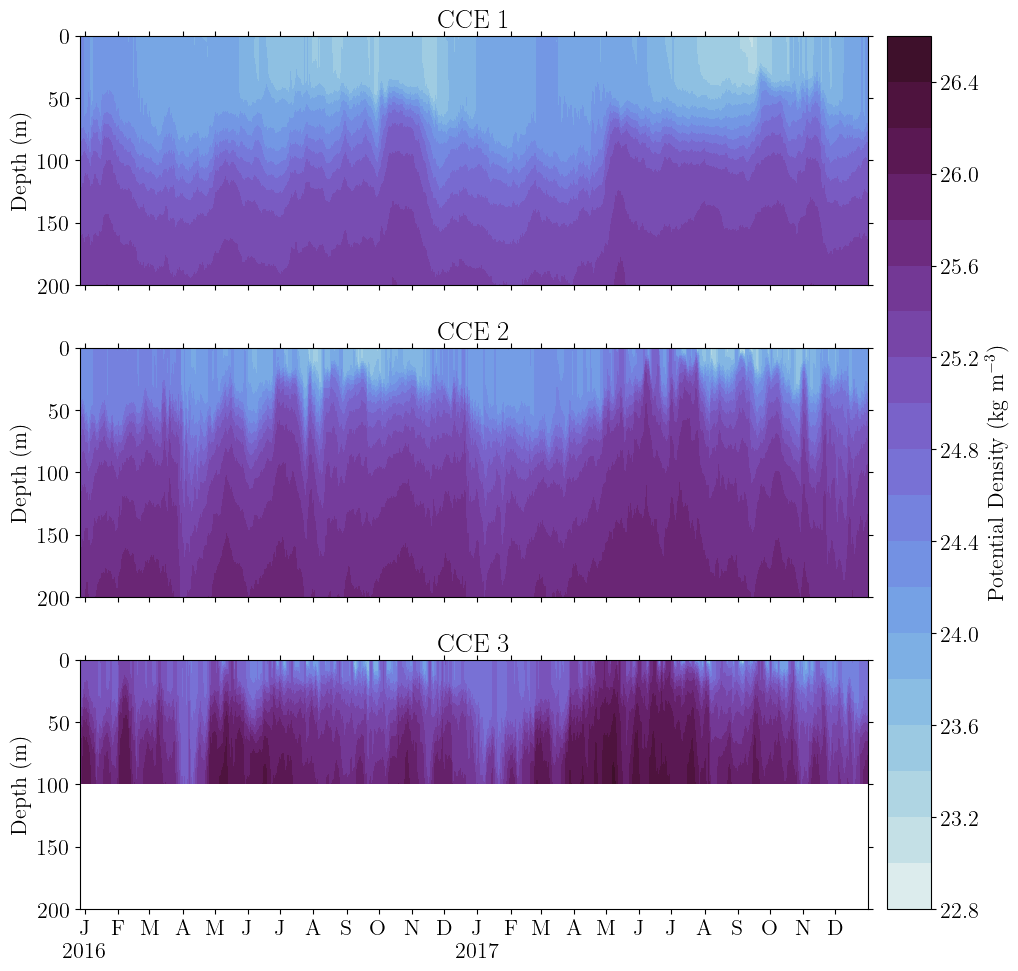

In [12]:
# Set the fontsize
plt.rcParams.update({'font.size': fontsize})

# Set plotting parameters
if option_var == 'temp':
    label = r'Conservative Temperature (deg C)'
    cmap = cmo.thermal
elif option_var == 'sal':
    label = r'Absolute Salinity (g/kg)'
    cmap = cmo.haline
elif option_var == 'density': 
    label = r'Potential Density (kg m$^{-3}$)'
    cmap = cmo.dense
elif option_var == 'u_along': 
    label = r'Along-shelf Velocity (ms$^{-1}$)'
    cmap = cmo.delta
elif option_var == 'v_cross': 
    label = r'Cross-shelf Velocity (ms$^{-1}$)'
    cmap = cmo.delta

# Create figure
fig,axes = plt.subplots(3,1,figsize=(12, 10))
ax1,ax2,ax3 =  axes.flatten()

# Loop through axes
for i, ax in enumerate(axes):

    # Plot temperature
    if (option_var == 'u_along') | (option_var == 'v_cross'): 
        cf = ax.contourf(time_dt,abs(depth),data[i,:,:].T, levels=20, cmap=cmap, vmin=-1.2, vmax=1.2)
    else:
        cf = ax.contourf(time_dt,abs(depth),data[i,:,:].T, levels=20, cmap=cmap)

    # Set axis attributes
    ax.set_title(f"CCE {i+1}")
    ax.set_ylim(0,200)
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.set_ylabel("Depth (m)")
    ax.tick_params(top=True, bottom=True, left=True, right=True,
                   direction='out', length=3.5)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))  
    if (i == 0) | (i == 1):
        ax.set_xticklabels([])

# Adjust layout before adding colorbar
plt.tight_layout()
fig.subplots_adjust(right=0.87)  # Make space on the right side

# Add shared colorbar
cbar = fig.colorbar(cf, ax=axes, location='right', pad=0.02)
cbar.set_label(label)

# Show figure
plt.show()

Compute the mixed layer depth as a function of time for each mooring location

In [6]:
# Set parameters
n_moor, n_time, n_depth = data.shape
phi = 100  # Units: J/m^2
g = 9.81   # Units: m/s^2

# Initialize arrays 
mld_THRESH = np.ma.masked_all((n_moor, n_time))
mld_GRAD   = np.ma.masked_all((n_moor, n_time))
mld_PE     = np.ma.masked_all((n_moor, n_time))

# Loop over moorings 
for imoor in range(n_moor):

    # Print state for ith mooring
    print(f'Computing MLD for mooring {imoor+1}/{data.shape[0]} ...')
    
    # Loop over time
    for it in range(n_time):

        # Extract density profile at this mooring and time
        rho_prof = data[imoor, it, :]
        
        # Skip fully masked profiles
        if rho_prof.mask.all():
            continue
        
        # Compute MLD using the potential energy anomaly method
        mld_THRESH[imoor, it] = compute_mld(abs(depth), density=rho_prof, method='threshold', dSigma=0.03, zref=10)
        mld_GRAD[imoor, it]   = compute_mld(abs(depth), density=rho_prof, method='gradient', gradSigma=0.009)
        mld_PE[imoor, it]     = compute_mld(abs(depth), density=rho_prof, method='potential_energy', phi=200)

# Mask invalid or missing values
mld_THRESH = np.ma.masked_invalid(mld_THRESH)
mld_GRAD   = np.ma.masked_invalid(mld_GRAD)
mld_PE     = np.ma.masked_invalid(mld_PE)

# Compute the mean variance in the mixed layer depth at each mooring site
mld_m = np.ma.mean(mld_THRESH,axis=1)
mld_var = np.ma.var(mld_THRESH,axis=1,ddof=1)

Computing MLD for mooring 1/3 ...
Computing MLD for mooring 2/3 ...
Computing MLD for mooring 3/3 ...


Compute a monthly climatology of mixed layer depths

In [7]:
# Compute the elapsed time from beginning of time series (units: seconds)
t0 = time[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time])

# Convert time array to year and month integers
years  = np.array([t.year for t in time_dt])
months = np.array([t.month for t in time_dt])

# Combine into "year-month" unique identifiers (e.g., 202301 for Jan 2023)
yearmonth = years * 100 + months
unique_months = np.unique(yearmonth)

# Preallocate masked arrays for results
mld_monthly_mean  = np.ma.masked_all((n_moor, len(unique_months)))
mld_monthly_var   = np.ma.masked_all((n_moor, len(unique_months)))
mld_monthly_std   = np.ma.masked_all((n_moor, len(unique_months)))
mld_monthly_stdm  = np.ma.masked_all((n_moor, len(unique_months)))
mld_monthly_stdv  = np.ma.masked_all((n_moor, len(unique_months)))
Lt_days           = np.ma.masked_all((n_moor, len(unique_months)))

# Loop over moorings and months
for imoor in range(n_moor):
    for im, ym in enumerate(unique_months):

        # Select all time indices belonging to this month
        idx = np.where(yearmonth == ym)[0]
        if idx.size == 0:
            continue
        
        # Extract MLD values for that mooring and month
        vals = mld_PE[imoor, idx]
        itime = time_elapsed[idx]

        # Skip if all masked
        if vals.mask.all():
            continue

        # Compute monthly mean and variance ignoring masked values
        mld_monthly_mean[imoor, im] = np.ma.mean(vals)
        mld_monthly_var[imoor, im]  = np.ma.var(vals,ddof=1)
        mld_monthly_std[imoor, im]  = np.ma.std(vals,ddof=1)

        # Compute the decorrelation scale 
        vals_dt = detrend(vals, itime, mean = 0)
        autocorr, _, _, _, lag_time, _ = compute_autocorr_optimize(vals_dt, itime, len(itime), 'biased', 0)
        Lt = compute_decor_scale_optimize(autocorr,lag_time,T,'unbiased',0)

        # Convert decorrelation scale to units of days
        Lt_days[imoor,im] = Lt*(1/60)*(1/60)*(1/24)

        # Compute the number of degrees of freedom at each site
        T_days = T*(1/60)*(1/60)*(1/24)
        n_d = Lt_days[imoor,im]/T_days
        N_eff = len(itime)/n_d

        # Compute the standard error of the mean and variance
        mld_monthly_stdm[imoor, im] = mld_monthly_std[imoor, im] / np.sqrt(N_eff)
        mld_monthly_stdv[imoor, im] = mld_monthly_var[imoor, im] * np.sqrt(2/(N_eff-1))

# Create simple arrays of the corresponding (year, month)
month_years = unique_months // 100
month_nums  = unique_months % 100

# Combine into datetime objects (using the first day of each month)
monthly_time = np.array([
    datetime(int(y), int(m), 1) for y, m in zip(month_years, month_nums)
])

Plot the performance of the mixed layer depth computation

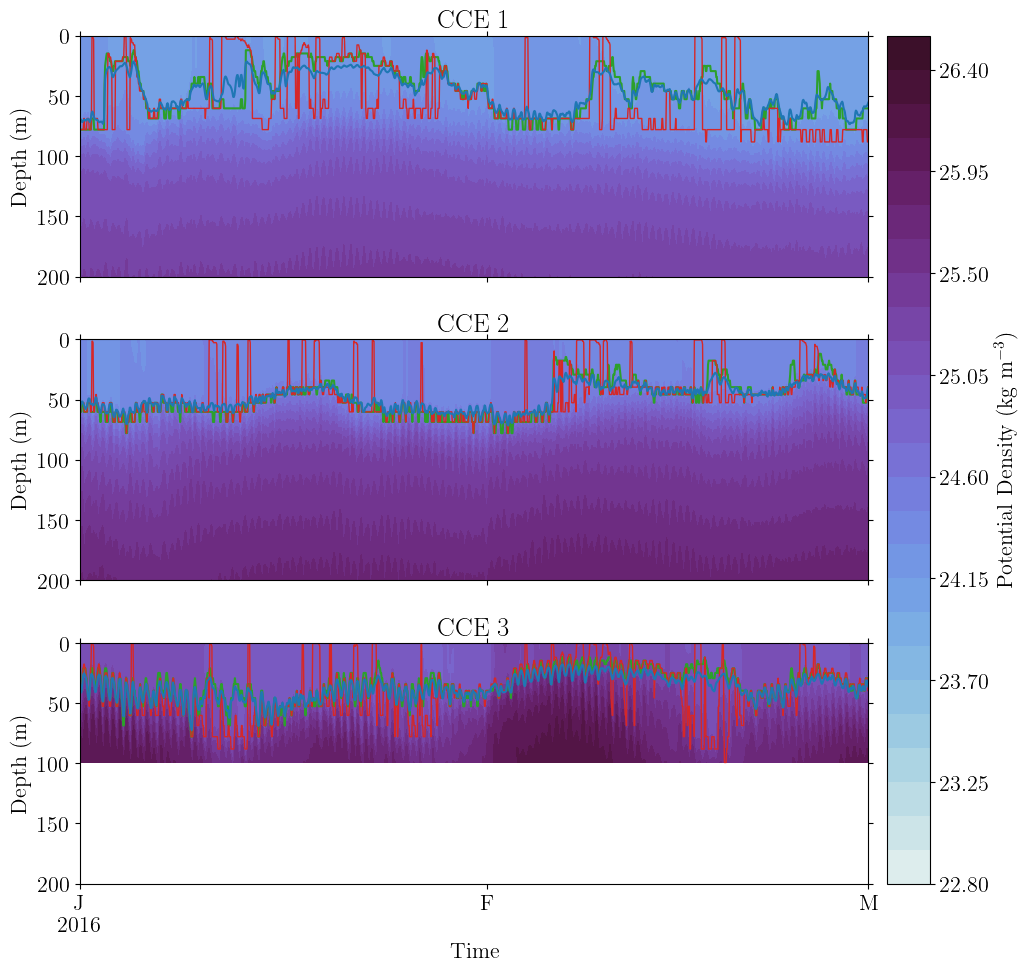

In [8]:
# Set parameters
start_date = datetime(2016, 1, 1)
end_date   = datetime(2016, 3, 1)

# Create figure
fig,axes = plt.subplots(3,1,figsize=(12, 10))
ax1,ax2,ax3 =  axes.flatten()

# Loop through axes
for i, ax in enumerate(axes):

    # Plot data
    if (option_var == 'u_along') | (option_var == 'v_cross'): 
        cf = ax.contourf(time_dt,abs(depth),data[i,:,:].T, levels=30, cmap=cmap, vmin=-1.2, vmax=1.2)
    else:
        cf = ax.contourf(time_dt,abs(depth),data[i,:,:].T, levels=30, cmap=cmap)

    # Plot the mixed layer depth 
    ax.plot(time_dt,mld_THRESH[i,:], '-', color='tab:green', lw=1.5)
    ax.plot(time_dt,mld_GRAD[i,:], '-', color='tab:red', lw=1)
    ax.plot(time_dt,mld_PE[i,:], '-', color='tab:blue', lw=1.5)
    
    # Set axis attributes
    ax.set_title(f"CCE {i+1}")
    ax.set_xlim(start_date,end_date)
    ax.set_ylim(0,200)
    ax.invert_yaxis()
    ax.set_ylabel("Depth (m)")
    ax.tick_params(top=True, bottom=True, left=True, right=True,
                   direction='out', length=3.5)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))  
    if (i == 0) | (i == 1):
        ax.set_xticklabels([])
    if i == 2:
        ax.set_xlabel("Time")

# Adjust layout before adding colorbar
plt.tight_layout()
fig.subplots_adjust(right=0.87)  # Make space on the right side

# Add shared colorbar
cbar = fig.colorbar(cf, ax=axes, location='right', pad=0.02)
cbar.set_label(label)

# Show figure
plt.show()

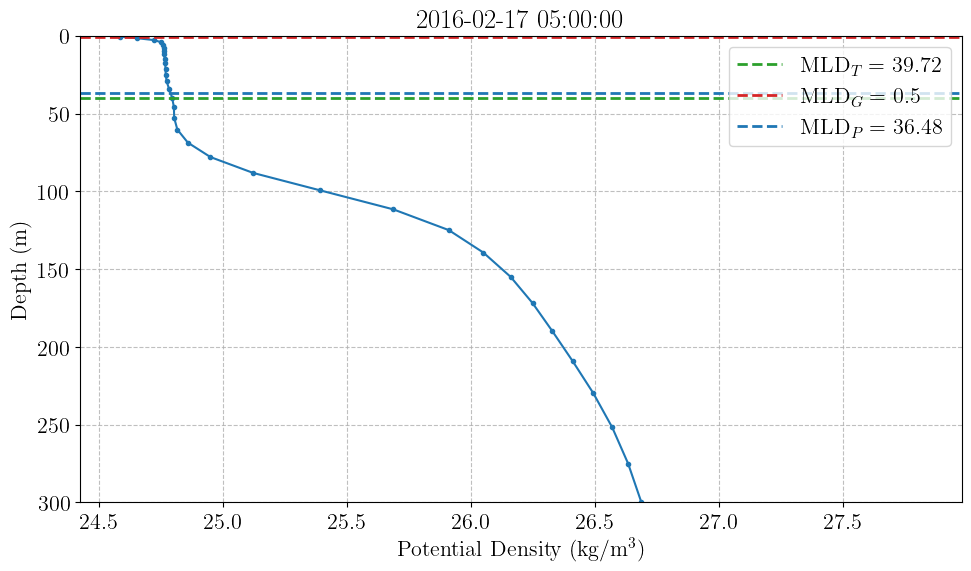

In [9]:
# Set parameters
itime = 1250
imoor = 0

# Create figure
fig,ax = plt.subplots(figsize=(10, 6))

# Plot a density profile
ax.plot(data[imoor,itime,:],abs(depth),'.-')

# Plot the mixed layer depth 
ax.axhline(mld_THRESH[imoor,itime], lw = 2, ls= '--', color='tab:green', label=r'MLD$_{T} = $ ' + str(np.round(mld_THRESH[imoor,itime],2)))
ax.axhline(mld_GRAD[imoor,itime], lw = 2, ls= '--', color='tab:red', label=r'MLD$_{G} = $ ' + str(np.round(mld_GRAD[imoor,itime],2)))
ax.axhline(mld_PE[imoor,itime], lw = 2, ls= '--', color='tab:blue', label=r'MLD$_{P} = $ ' + str(np.round(mld_PE[imoor,itime],2)))

# Set figure attributes
ax.set_xlabel(r'Potential Density (kg/m$^3$)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,300)
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(loc='upper right', fontsize=fontsize)
ax.set_title(time_dt[itime])

# Reverse the direction of the x-axis 
ax.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

Plot climatology of mixed layer depth

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_22422/78347268.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".-k" (-> color='k'). The keyword argument will take precedence.
  ax.plot(monthly_time,mld_monthly_mean[1,:], '.-k', color='tab:red', lw=1)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_22422/78347268.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".-k" (-> color='k'). The keyword argument will take precedence.
  ax.plot(monthly_time,mld_monthly_mean[2,:], '.-k', color='tab:blue', lw=1)


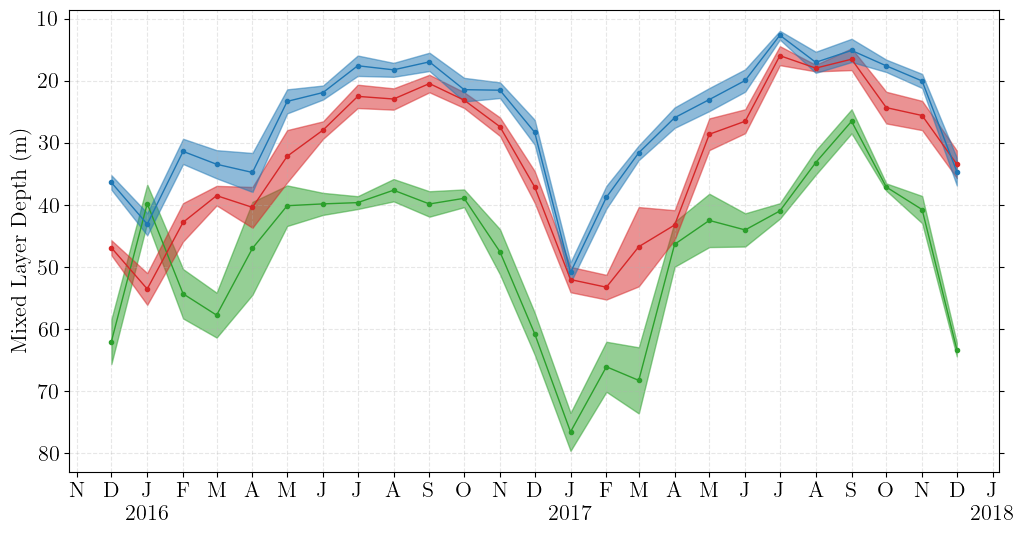

In [10]:
# Create figure
fig,ax = plt.subplots(figsize=(12, 6))

# Plot mixed layer depth variance for each mooring
ax.plot(monthly_time,mld_monthly_mean[0,:], '.-', color='tab:green', lw=1)
ax.plot(monthly_time,mld_monthly_mean[1,:], '.-k', color='tab:red', lw=1)
ax.plot(monthly_time,mld_monthly_mean[2,:], '.-k', color='tab:blue', lw=1)

# Plot standard error of the variance  for each mooring
ax.fill_between(monthly_time, mld_monthly_mean[0,:] - mld_monthly_stdm[0,:], mld_monthly_mean[0,:] + mld_monthly_stdm[0,:], color='tab:green', alpha=0.5)
ax.fill_between(monthly_time, mld_monthly_mean[1,:] - mld_monthly_stdm[1,:], mld_monthly_mean[1,:] + mld_monthly_stdm[1,:], color='tab:red', alpha=0.5)
ax.fill_between(monthly_time, mld_monthly_mean[2,:] - mld_monthly_stdm[2,:], mld_monthly_mean[2,:] + mld_monthly_stdm[2,:], color='tab:blue', alpha=0.5)

# Set axis attributes
ax.set_ylabel(r"Mixed Layer Depth (m)")
ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax.grid(True,linestyle='--',alpha=0.3)
ax.invert_yaxis()

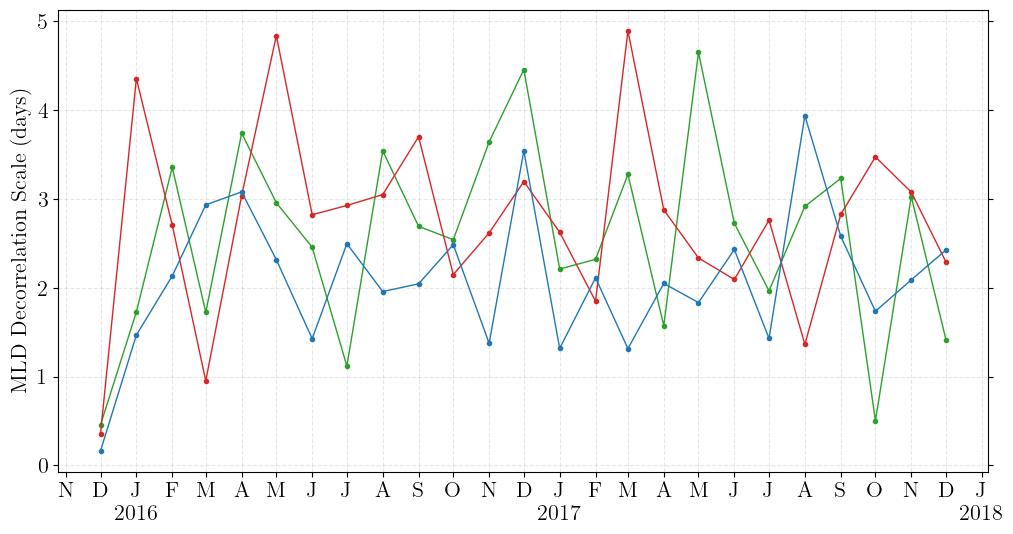

In [13]:
# Create figure
fig,ax = plt.subplots(figsize=(12, 6))

# Plot mixed layer depth variance for each mooring
ax.plot(monthly_time,Lt_days[0,:], '.-', color='tab:green', lw=1)
ax.plot(monthly_time,Lt_days[1,:], '.-', color='tab:red', lw=1)
ax.plot(monthly_time,Lt_days[2,:], '.-', color='tab:blue', lw=1)

# Set axis attributes
ax.set_ylabel(r"MLD Decorrelation Scale (days)")
ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax.grid(True,linestyle='--',alpha=0.3)

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_22422/4002416053.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".-k" (-> color='k'). The keyword argument will take precedence.
  ax.plot(monthly_time,mld_monthly_var[1,:], '.-k', color='tab:red', lw=1)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_22422/4002416053.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".-k" (-> color='k'). The keyword argument will take precedence.
  ax.plot(monthly_time,mld_monthly_var[2,:], '.-k', color='tab:blue', lw=1)


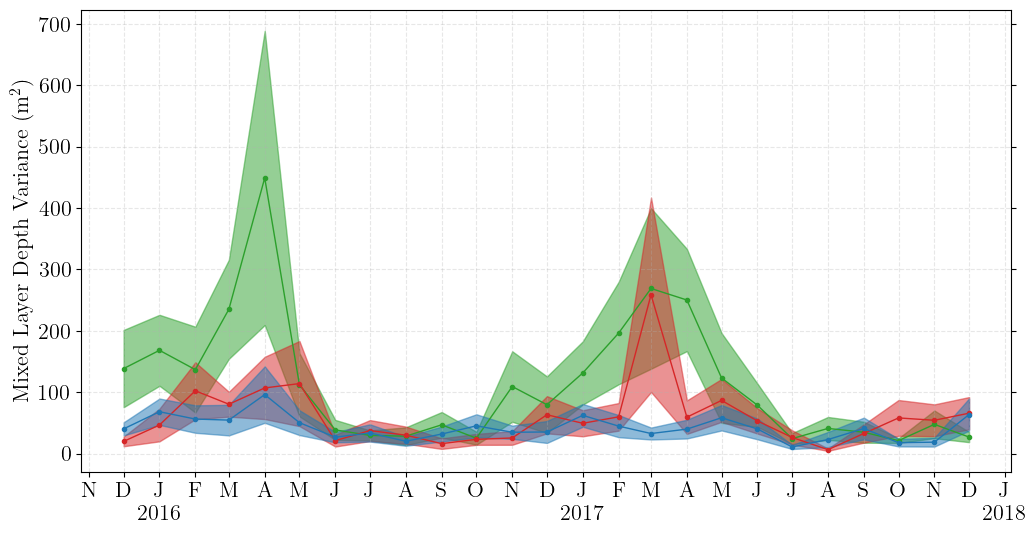

In [14]:
# Create figure
fig,ax = plt.subplots(figsize=(12, 6))

# Plot mixed layer depth variance for each mooring
ax.plot(monthly_time,mld_monthly_var[0,:], '.-', color='tab:green', lw=1)
ax.plot(monthly_time,mld_monthly_var[1,:], '.-k', color='tab:red', lw=1)
ax.plot(monthly_time,mld_monthly_var[2,:], '.-k', color='tab:blue', lw=1)

# Plot standard error of the variance  for each mooring
ax.fill_between(monthly_time, mld_monthly_var[0,:] - mld_monthly_stdv[0,:], mld_monthly_var[0,:] + mld_monthly_stdv[0,:], color='tab:green', alpha=0.5)
ax.fill_between(monthly_time, mld_monthly_var[1,:] - mld_monthly_stdv[1,:], mld_monthly_var[1,:] + mld_monthly_stdv[1,:], color='tab:red', alpha=0.5)
ax.fill_between(monthly_time, mld_monthly_var[2,:] - mld_monthly_stdv[2,:], mld_monthly_var[2,:] + mld_monthly_stdv[2,:], color='tab:blue', alpha=0.5)

# Set axis attributes
ax.set_ylabel(r"Mixed Layer Depth Variance (m$^2$)")
ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax.grid(True,linestyle='--',alpha=0.3)

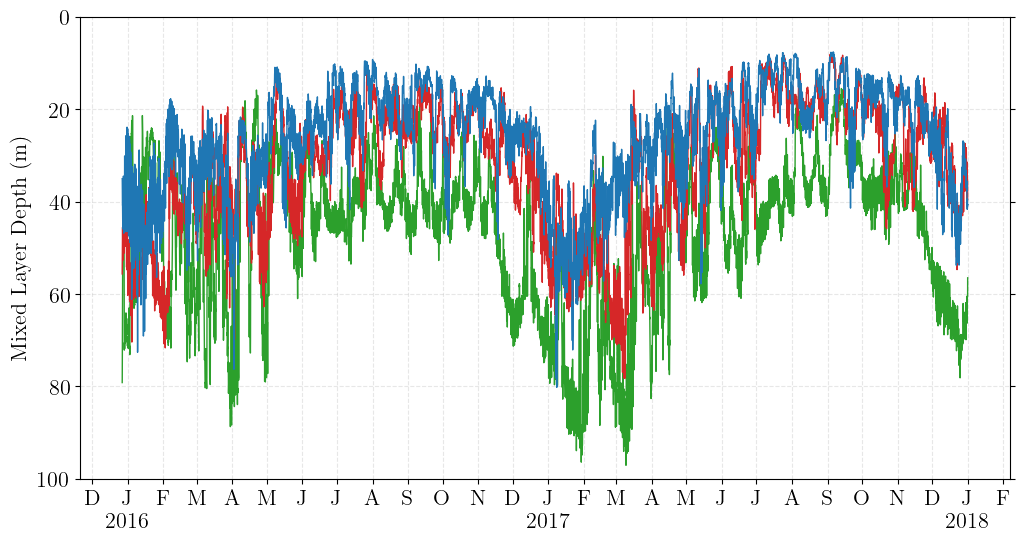

In [15]:
# Create figure
fig,ax = plt.subplots(figsize=(12, 6))

#--- Subplot 1 ---# 

# Plot CCE1 mixed layer depth
ax.plot(time_dt,mld_PE[0,:], '-', color='tab:green', lw=1)
ax.plot(time_dt,mld_PE[1,:], '-', color='tab:red', lw=1)
ax.plot(time_dt,mld_PE[2,:], '-', color='tab:blue', lw=1)

# Set axis attributes
ax.set_ylabel("Mixed Layer Depth (m)")
ax.set_ylim(0,100)
ax.invert_yaxis()
ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax.grid(True,linestyle='--',alpha=0.3)

# Developmental Code 

In [ ]:

        #----------------------
        # Debug PEA Method
        #----------------------

        # Set input parameters
        z = abs(depth)
        rho_prof = rho_prof

        # Convert inputs to numpy arrays for safe indexing
        z = np.asarray(z)
        if rho_prof is not None: rho_prof = np.ma.masked_invalid(rho_prof)

        # Ensure depth increases with index (surface first, deep last)
        if z[0] > z[-1]:
            z = z[::-1]
            if rho_prof is not None: rho_prof = rho_prof[::-1]

        # Define mask for non-masked data-depth pairs (set mask to all False if arr is not a masked array)
        mask = ~rho_prof.mask if np.ma.isMaskedArray(rho_prof) else np.ones_like(rho_prof, dtype=bool)

        # Ensure mask only keeps finite values (no NaN or +/- inf)
        mask &= np.isfinite(rho_prof)

        # Remove masked values
        depth_valid, dens_valid = z[mask], rho_prof[mask]
        
        # Compute the vertical spacing between depth levels and rename the density variable
        rho = dens_valid
        dz = np.diff(depth_valid)
        H  = np.cumsum(dz) 

        # Compute the cumulative integral of rho(z) (estimate of the total mass per area of the water column from the surface down to each depth level)
        rho_m_int = np.cumsum(rho[:-1] * dz)

        # Compute the mean density of the layer from the surface to each depth (average density of the water column above each depth)
        rho_m = rho_m_int / H

        # Compute the local contribution to the potential energy anonaly at each depth
        integrand = (rho[:-1] - rho_m) * g * depth_valid[:-1]

        # Compute the total potential energy per unit area needed to mixed the fluid uniformly to each depth level
        pe_anomaly = np.cumsum(integrand * dz)

        # Compute the difference between the computed PEA and the target threshold 
        pea_diff = pe_anomaly - phi

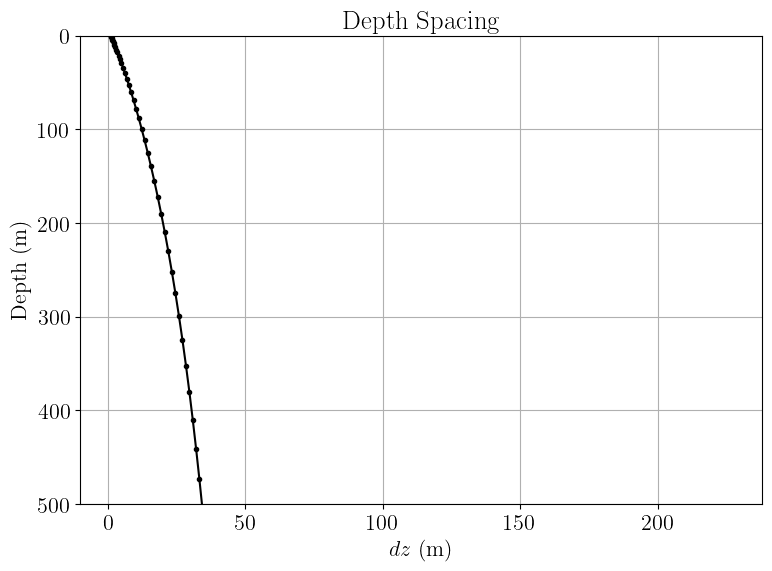

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(dz, abs(depth_valid[:-1]), '.-k')

ax.set_xlabel(r'$dz$ (m)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,500)
ax.invert_yaxis()
ax.grid()

ax.set_title('Depth Spacing')
plt.tight_layout()
plt.show()

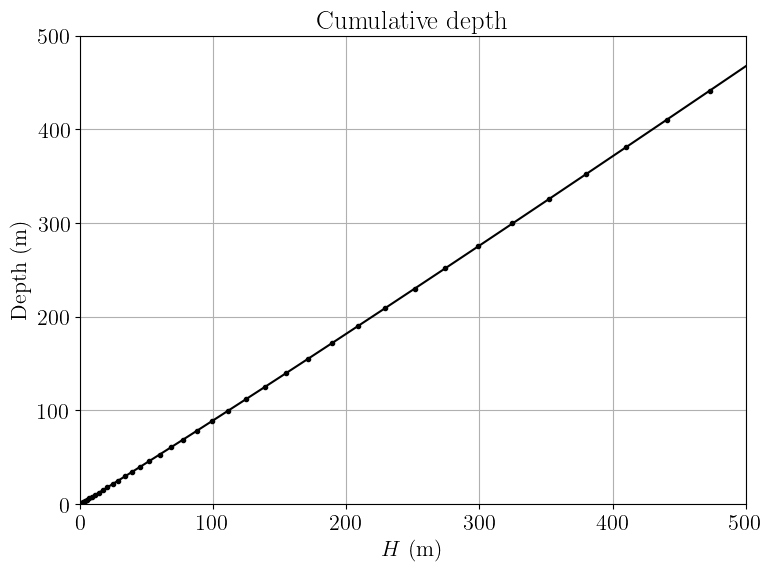

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(H, abs(depth_valid[:-1]), '.-k')

ax.set_xlabel(r'$H$ (m)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,500)
ax.set_ylim(0,500)
ax.grid()

ax.set_title('Cumulative depth')
plt.tight_layout()
plt.show()

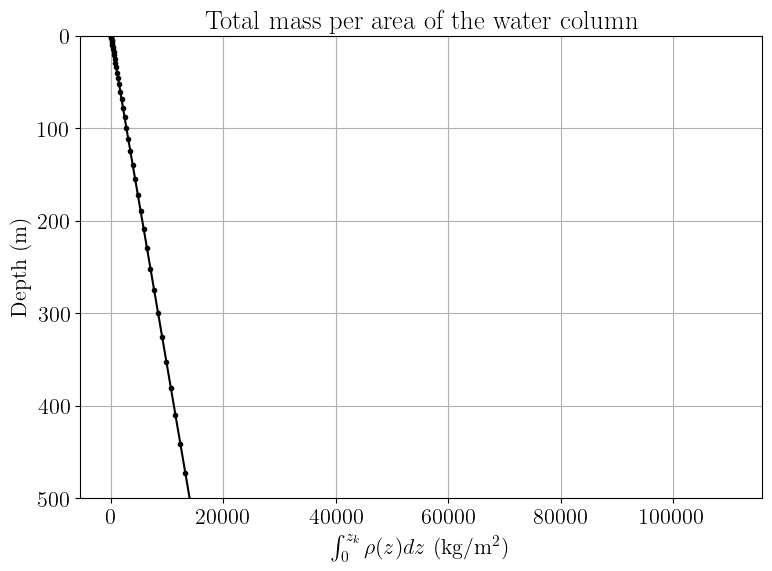

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rho_m_int, abs(depth_valid[:-1]), '.-k')

ax.set_xlabel(r'$\int_0^{z_k} \rho(z) dz$ (kg/m$^2$)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,500)
ax.invert_yaxis()
ax.grid()

ax.set_title('Total mass per area of the water column')
plt.tight_layout()
plt.show()

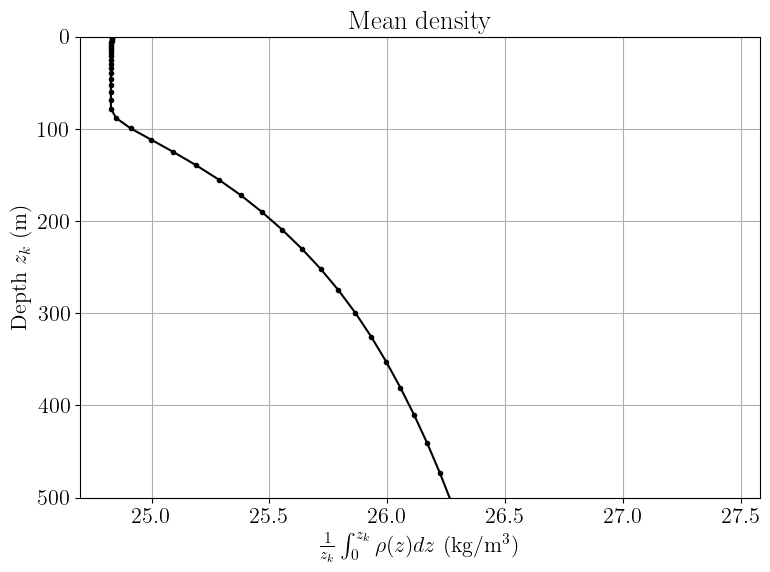

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rho_m, abs(depth_valid[:-1]), '.-k')

ax.set_xlabel(r'$\frac{1}{z_k} \int_0^{z_k} \rho(z) dz$ (kg/m$^3$)')
ax.set_ylabel(r'Depth $z_k$ (m)')
ax.set_ylim(0,500)
ax.invert_yaxis()
ax.grid()

ax.set_title('Mean density')
plt.tight_layout()
plt.show()

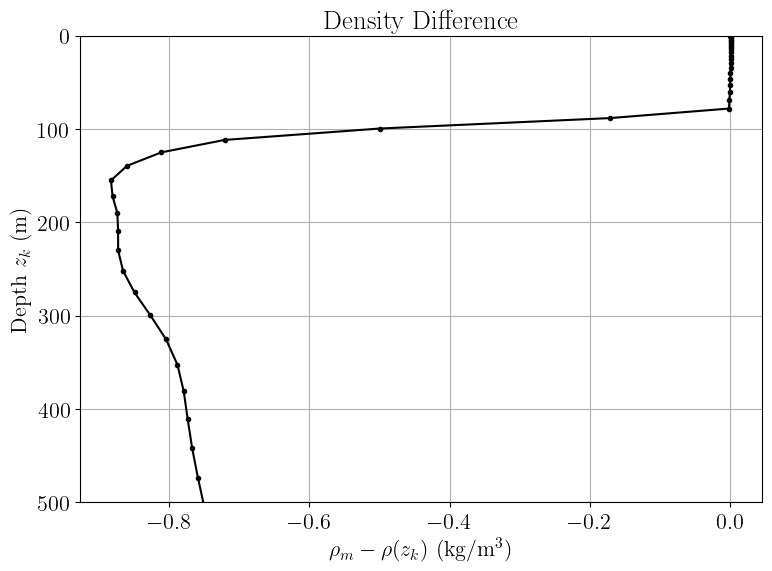

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rho_diff, abs(depth_valid[:-1]), '.-k')

ax.set_xlabel(r'$\rho_m - \rho(z_k)$ (kg/m$^3$)')
ax.set_ylabel(r'Depth $z_k$ (m)')
ax.set_ylim(0,500)
ax.invert_yaxis()
ax.grid()

ax.set_title('Density Difference')
plt.tight_layout()
plt.show()

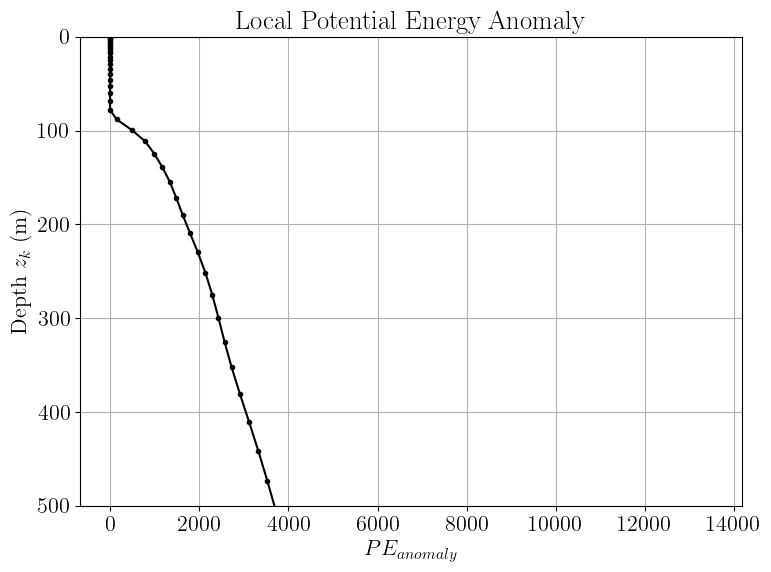

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(integrand, abs(depth_valid[:-1]), '.-k')

ax.set_xlabel(r'$PE_{anomaly}$')
ax.set_ylabel(r'Depth $z_k$ (m)')
ax.set_ylim(0,500)
ax.invert_yaxis()
ax.grid()

ax.set_title('Local Potential Energy Anomaly')
plt.tight_layout()
plt.show()

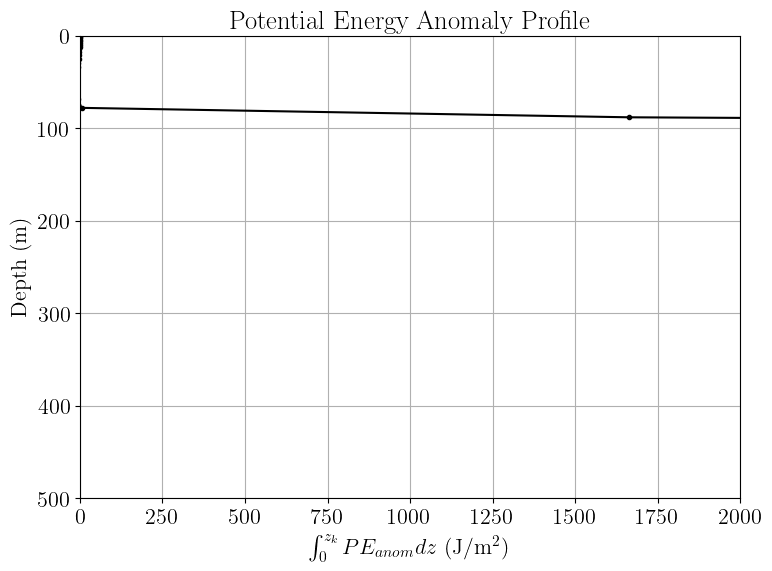

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(pe_anomaly, abs(depth_valid[:-1]), '.-k')

ax.set_xlabel(r'$\int_0^{z_k} PE_{anom} dz$ (J/m$^2$)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,2000)
ax.set_ylim(0,500)
ax.invert_yaxis()
ax.grid()

ax.set_title('Potential Energy Anomaly Profile')
plt.tight_layout()
plt.show()